In [1]:
# 导入库
import wrds
import pandas as pd

# 连接 WRDS（把 '你的用户名' 换成你的 WRDS 账号）
db = wrds.Connection(wrds_username='你的用户名')

# 测试连接：列出所有数据库
print(db.list_libraries())

# 测试：查看 comp 数据库里有哪些表
print(db.list_tables('comp'))

# 连接成功后关闭
db.close()

/Users/au/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Enter your WRDS username [你的用户名]:jinzichun
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
['aha_sample', 'ahasamp', 'auditsmp', 'auditsmp_all', 'bank', 'bank_all', 'bank_premium_samp', 'banksamp', 'block', 'block_all', 'boardex_trial', 'boardsmp', 'bvd', 'bvd_amadeus_trial', 'bvd_bvdbankf', 'bvd_bvdbankf_trial', 'bvd_orbis_trial', 'bvdsamp', 'calcbench_trial', 'calcbnch', 'candid_samp', 'cboe', 'cboe_all', 'cboe_sample', 'cboesamp', 'cddsamp', 'ciq', 'ciq_capstrct', 'ciq_common', 'ciqsamp', 'ciqsamp_capstrct', 'ciqsamp_common', 'ciqsamp_keydev', 'ciqsamp_pplintel', 'ciqsamp_ratings', 'ciqsamp_transactions', 'ciqsamp_transcripts', 'cisdmsmp', 'columnar', 'comp', 'comp_execucomp', 'comp_global_daily', 'comp_na_daily_all', 'comp_urq', 'comph', 'compsamp', 'compsamp_all', 'compsamp_co

In [5]:
# 定义要查询的公司和年份
tickers = "('WMT', 'TGT')"
start_year = 2020
end_year = 2025

# 修正后的SQL查询语句 (移除了 lteq)
sql_query = f"""
SELECT 
    tic,
    fyear,
    sale,
    cogs,
    ni,
    at,
    invt,
    teq
FROM comp.funda
WHERE tic IN {tickers}
    AND fyear BETWEEN {start_year} AND {end_year}
    AND indfmt = 'INDL'
    AND datafmt = 'STD'
    AND popsrc = 'D'
    AND consol = 'C'
ORDER BY tic, fyear
"""

# 执行查询
data = db.raw_sql(sql_query)

# 查看结果
print("数据前5行：")
print(data.head())

print("\n数据形状：")
print(data.shape)

print("\n各公司年份分布：")
print(data.groupby('tic')['fyear'].value_counts().sort_index())

# 保存数据
data.to_csv('wmt_tgt_raw.csv', index=False)
print("\n✅ 数据已保存到 wmt_tgt_raw.csv")

数据前5行：
   tic  fyear      sale     cogs      ni       at     invt      teq
0  TGT   2020   93561.0  65696.0  4368.0  51248.0  10653.0  14440.0
1  TGT   2021  106005.0  74665.0  6946.0  53811.0  13902.0  12827.0
2  TGT   2022  109120.0  81914.0  2780.0  53335.0  13499.0  11232.0
3  TGT   2023  107412.0  77350.0  4138.0  55356.0  11886.0  13432.0
4  TGT   2024  106566.0  76050.0  4091.0  57769.0  12740.0  14666.0

数据形状：
(12, 8)

各公司年份分布：
tic  fyear
TGT  2020     1
     2021     1
     2022     1
     2023     1
     2024     1
     2025     1
WMT  2020     1
     2021     1
     2022     1
     2023     1
     2024     1
     2025     1
Name: count, dtype: Int64

✅ 数据已保存到 wmt_tgt_raw.csv


In [6]:
# 创建一个新的 DataFrame 来存放计算结果
df = data.copy()

# 1. 毛利率 = (营业收入 - 销售成本) / 营业收入
df['gross_margin'] = (df['sale'] - df['cogs']) / df['sale']

# 2. 净利率 = 净利润 / 营业收入
df['net_margin'] = df['ni'] / df['sale']

# 3. 资产回报率 ROA = 净利润 / 总资产
df['roa'] = df['ni'] / df['at']

# 4. 净资产收益率 ROE = 净利润 / 股东权益
df['roe'] = df['ni'] / df['teq']

# 5. 存货周转率 = 销售成本 / 存货
df['inventory_turnover'] = df['cogs'] / df['invt']

# 查看计算结果
print("===== 计算完成！以下是两家公司的财务比率 =====\n")
print(df[['tic', 'fyear', 'gross_margin', 'net_margin', 'roa', 'roe', 'inventory_turnover']])

# 保存计算结果
df.to_csv('wmt_tgt_ratios.csv', index=False)
print("\n✅ 比率计算结果已保存到 wmt_tgt_ratios.csv")


===== 计算完成！以下是两家公司的财务比率 =====

    tic  fyear  gross_margin  net_margin       roa       roe  \
0   TGT   2020      0.297827    0.046686  0.085233  0.302493   
1   TGT   2021      0.295646    0.065525  0.129081  0.541514   
2   TGT   2022      0.249322    0.025477  0.052123  0.247507   
3   TGT   2023      0.279876    0.038525  0.074753   0.30807   
4   TGT   2024      0.286358    0.038389  0.070817  0.278944   
5   TGT   2025      0.284272     0.03536  0.062279  0.229199   
6   WMT   2020      0.265328    0.024258  0.053506  0.154345   
7   WMT   2021      0.266018    0.023989   0.05584  0.148796   
8   WMT   2022      0.255891    0.019195  0.048027  0.139456   
9   WMT   2023      0.259313    0.024021  0.061454  0.171679   
10  WMT   2024      0.264703    0.028652  0.074518  0.199505   
11  WMT   2025      0.266879      0.0308  0.076907  0.206758   

    inventory_turnover  
0             6.166901  
1              5.37081  
2             6.068153  
3             6.507656  
4          

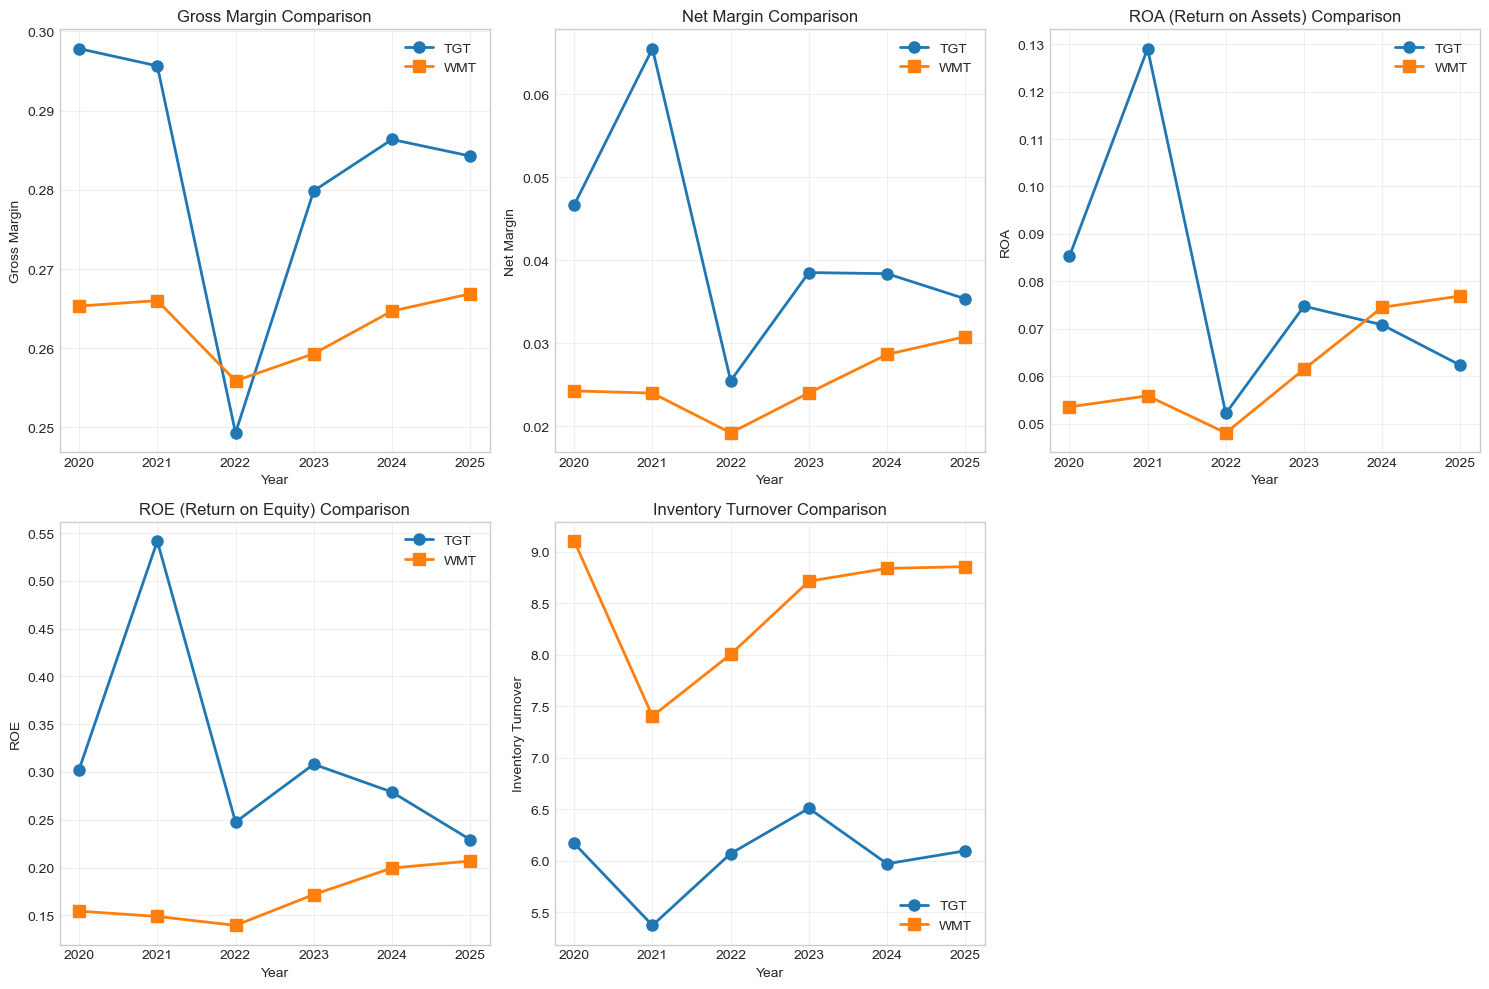

✅ 图表已保存为 wmt_tgt_comparison.png


In [8]:
# ============================================
# 画图：可视化两家公司的财务比率对比

import matplotlib.pyplot as plt

# 分别提取两家公司的数据
tgt = df[df['tic'] == 'TGT'].copy()
wmt = df[df['tic'] == 'WMT'].copy()

# 设置图表样式
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 图1：毛利率对比
axes[0, 0].plot(tgt['fyear'], tgt['gross_margin'], 'o-', linewidth=2, markersize=8, label='TGT')
axes[0, 0].plot(wmt['fyear'], wmt['gross_margin'], 's-', linewidth=2, markersize=8, label='WMT')
axes[0, 0].set_title('Gross Margin Comparison', fontsize=12)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Gross Margin')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 图2：净利率对比
axes[0, 1].plot(tgt['fyear'], tgt['net_margin'], 'o-', linewidth=2, markersize=8, label='TGT')
axes[0, 1].plot(wmt['fyear'], wmt['net_margin'], 's-', linewidth=2, markersize=8, label='WMT')
axes[0, 1].set_title('Net Margin Comparison', fontsize=12)
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Net Margin')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 图3：ROA 对比
axes[0, 2].plot(tgt['fyear'], tgt['roa'], 'o-', linewidth=2, markersize=8, label='TGT')
axes[0, 2].plot(wmt['fyear'], wmt['roa'], 's-', linewidth=2, markersize=8, label='WMT')
axes[0, 2].set_title('ROA (Return on Assets) Comparison', fontsize=12)
axes[0, 2].set_xlabel('Year')
axes[0, 2].set_ylabel('ROA')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 图4：ROE 对比
axes[1, 0].plot(tgt['fyear'], tgt['roe'], 'o-', linewidth=2, markersize=8, label='TGT')
axes[1, 0].plot(wmt['fyear'], wmt['roe'], 's-', linewidth=2, markersize=8, label='WMT')
axes[1, 0].set_title('ROE (Return on Equity) Comparison', fontsize=12)
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('ROE')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 图5：存货周转率对比
axes[1, 1].plot(tgt['fyear'], tgt['inventory_turnover'], 'o-', linewidth=2, markersize=8, label='TGT')
axes[1, 1].plot(wmt['fyear'], wmt['inventory_turnover'], 's-', linewidth=2, markersize=8, label='WMT')
axes[1, 1].set_title('Inventory Turnover Comparison', fontsize=12)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Inventory Turnover')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 隐藏第6个子图（因为用不到）
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('wmt_tgt_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ 图表已保存为 wmt_tgt_comparison.png")